# Introducing the Mapper Algorithm: Finding Shape in Medical Data

Welcome! In this notebook, you will explore **Mapper**, a tool from topological data analysis (TDA) that reveals the hidden structure and patterns in data. We'll use real medical datasets and you'll be able to change parameters to see how they affect the results.

**What you'll need**: A Google account. That's it! Everything runs in the browser.

## Section 0: Setup

Run this cell once to install the Mapper library. On Google Colab you only need to do this once per session.

In [1]:
!pip install kmapper -q

## Section 1: What is the "Shape" of Data?

Imagine you have two piles of coins. In both piles, the average weight and spread of weights are exactly the same. But in one pile, the coins form a ring—light coins on the outside, heavy coins on the inside. In the other pile, they're arranged in a line from light to heavy. The statistics are identical, but the *structure* is completely different.

**This is what Mapper cares about**: not just numbers and averages, but the *connections and branching* in your data.

Think of it this way:
- A **street map** shows the topology of a city: which streets connect, where intersections are, how neighborhoods branch off. It doesn't tell you the exact distance between two points (that's for satellite photos).
- **Mapper works like a cartographer**: it takes complex, high-dimensional data and creates a simplified "map" that shows you the essential structure—where data clusters, where they branch, how different groups relate.

In medicine, this can reveal previously unknown patient subtypes, disease progression patterns, or unexpected connections in biological data.

## Section 2: The Mapper Algorithm in 4 Steps

Mapper works by following a simple four-step process. Let's imagine you're organizing a large group of students by similarity.

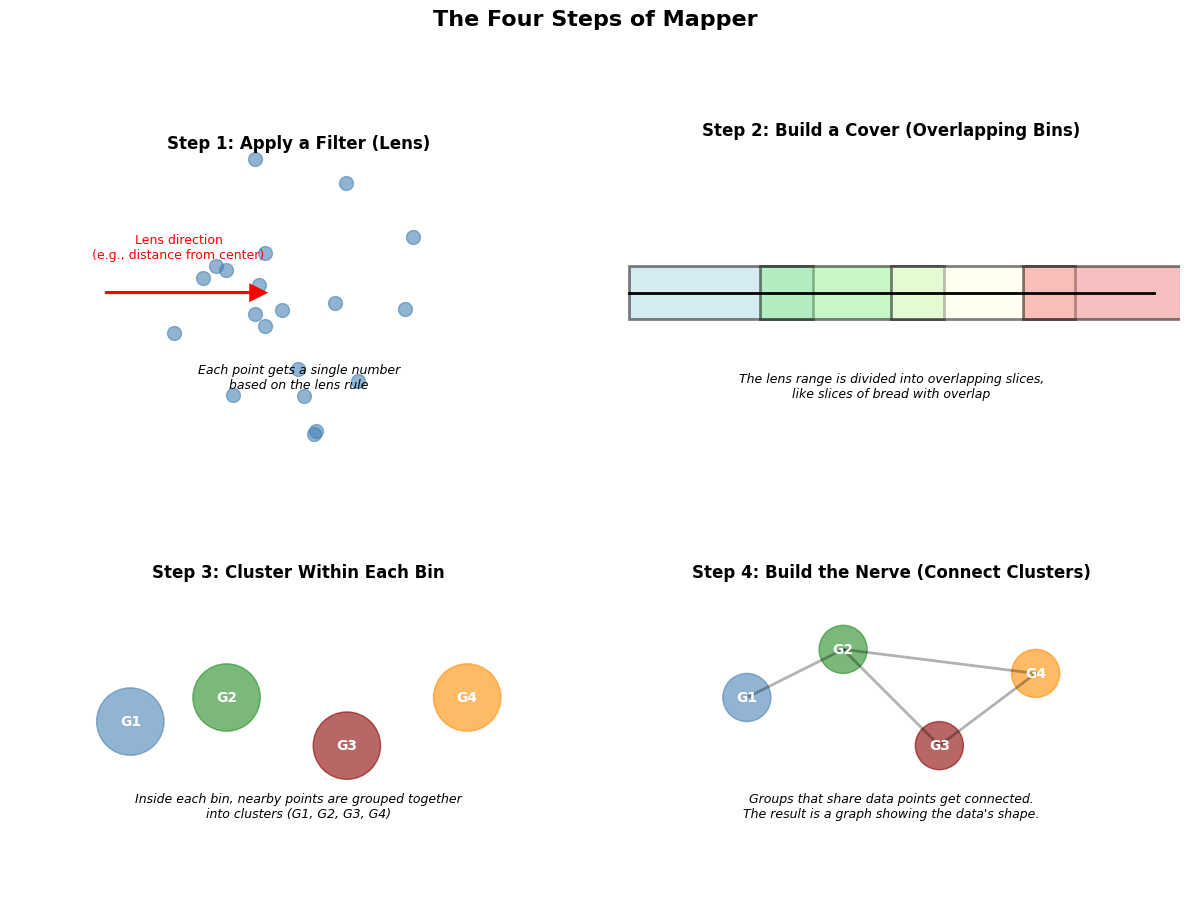

The Mapper algorithm condenses high-dimensional data into a simple graph.
This graph preserves the 'skeleton' of the data's structure.


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('The Four Steps of Mapper', fontsize=16, fontweight='bold')

# Step 1: Filter Function
ax = axes[0, 0]
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.text(5, 5.5, 'Step 1: Apply a Filter (Lens)', fontsize=12, fontweight='bold', ha='center')
# Draw scattered points
np.random.seed(42)
pts = np.random.randn(20, 2) * 1.5 + np.array([5, 2.5])
ax.scatter(pts[:, 0], pts[:, 1], s=100, alpha=0.6, color='steelblue')
# Draw an arrow showing the "lens" direction
ax.arrow(1, 2.5, 3, 0, head_width=0.3, head_length=0.3, fc='red', ec='red', linewidth=2)
ax.text(2.5, 3.2, 'Lens direction\n(e.g., distance from center)', fontsize=9, ha='center', color='red')
ax.text(5, 0.5, 'Each point gets a single number\nbased on the lens rule', fontsize=9, ha='center', style='italic')

# Step 2: Cover
ax = axes[0, 1]
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.text(5, 5.5, 'Step 2: Build a Cover (Overlapping Bins)', fontsize=12, fontweight='bold', ha='center')
# Draw a number line with overlapping intervals
ax.plot([0, 10], [2.5, 2.5], 'k-', linewidth=2)
colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']
for i in range(4):
    start = i * 2.5
    end = start + 3.5
    rect = patches.Rectangle((start, 2), end - start, 1, linewidth=2, edgecolor='black', facecolor=colors[i], alpha=0.5)
    ax.add_patch(rect)
ax.text(5, 0.5, 'The lens range is divided into overlapping slices,\nlike slices of bread with overlap', fontsize=9, ha='center', style='italic')

# Step 3: Cluster
ax = axes[1, 0]
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.text(5, 5.5, 'Step 3: Cluster Within Each Bin', fontsize=12, fontweight='bold', ha='center')
# Draw bins with clusters inside
colors = ['steelblue', 'forestgreen', 'darkred', 'darkorange']
positions = [(1.5, 2.5), (3.5, 3), (6, 2), (8.5, 3)]
for i, (x, y) in enumerate(positions):
    circle = plt.Circle((x, y), 0.7, color=colors[i], alpha=0.6)
    ax.add_patch(circle)
    ax.text(x, y, f'G{i+1}', ha='center', va='center', color='white', fontweight='bold')
ax.text(5, 0.5, 'Inside each bin, nearby points are grouped together\ninto clusters (G1, G2, G3, G4)', fontsize=9, ha='center', style='italic')

# Step 4: Graph
ax = axes[1, 1]
ax.set_xlim(-1, 11)
ax.set_ylim(-1, 6)
ax.set_aspect('equal')
ax.axis('off')
ax.text(5, 5.5, 'Step 4: Build the Nerve (Connect Clusters)', fontsize=12, fontweight='bold', ha='center')
# Draw a simple graph
positions_graph = [(2, 3), (4, 4), (6, 2), (8, 3.5)]
labels = ['G1', 'G2', 'G3', 'G4']
for i, (x, y) in enumerate(positions_graph):
    circle = plt.Circle((x, y), 0.5, color=colors[i], alpha=0.6)
    ax.add_patch(circle)
    ax.text(x, y, labels[i], ha='center', va='center', color='white', fontweight='bold', fontsize=10)
# Draw edges
edges = [(0, 1), (1, 2), (1, 3), (2, 3)]
for i, j in edges:
    x1, y1 = positions_graph[i]
    x2, y2 = positions_graph[j]
    ax.plot([x1, x2], [y1, y2], 'k-', linewidth=2, alpha=0.3)
ax.text(5, 0.5, 'Groups that share data points get connected.\nThe result is a graph showing the data\'s shape.', fontsize=9, ha='center', style='italic')

plt.tight_layout()
plt.show()

print("The Mapper algorithm condenses high-dimensional data into a simple graph.")
print("This graph preserves the 'skeleton' of the data's structure.")

## Section 3: Parameters You Can Change

The Mapper algorithm has three main dials you can turn to change what it reveals:

### 1. **The Filter Function** ("The Sorting Rule")
Before Mapper starts, you pick one thing to measure about each data point. This measurement becomes a single number that ranks each point. Think of it like sorting students by height before grouping them:
- **"distance_from_center"**: How far each patient is from the middle of the data (like a target: center = bullseye, edge = far from average)
- **"main_direction"**: The first direction of most variation (like finding the main trend in the data)
- **"how_isolated"**: How far each patient is from their neighbors (like asking: "Are you in the crowd or on the edge?")

### 2. **Resolution** ("Number of Slices")
How many bins (slices) should we cut the data into? 
- Lower numbers (3–5) = coarse picture, fewer nodes, simpler graph
- Higher numbers (15–30) = fine detail, more nodes, more complex graph
- Try 10 as a starting point

### 3. **Overlap Percentage** ("How Much Slices Overlap")
How much should neighboring slices overlap?
- Low overlap (10–20%) = sparse connections, graph may break apart
- Medium overlap (40–60%) = a good balance (usually 50%)
- High overlap (70%+) = everything meshes together, structure blurs

The overlap is the "glue" that connects the graph: without it, every cluster would be isolated.

### ⬇️ HERE ARE THE PARAMETERS YOU CAN CHANGE ⬇️

Edit the values below, then run the remaining cells to see how the graph changes:

In [3]:
# ← CHANGE THESE VALUES ←

# Which lens (filter function) to use?
# Options: "distance_from_center", "main_direction", "how_isolated"
filter_choice = "distance_from_center"

# How many slices to divide the data into? (5-30 is typical)
n_intervals = 10

# What percentage overlap between slices? (10-70 is typical, 50 is common)
overlap_pct = 50

## Section 4: Choose Your Data

Pick a dataset to analyze. We'll start with **Iris** (a classic flower dataset, 150 plants) for a quick demo, then you can switch to **Breast Cancer** (569 patients, real medical data) for a more meaningful exploration.

In [4]:
# ← CHANGE THIS ←
# Options: "iris" or "breast_cancer"
DATASET = "iris"

In [5]:
from sklearn.datasets import load_iris, load_breast_cancer
import pandas as pd
import numpy as np

if DATASET == "iris":
    data = load_iris()
    X = data.data
    y = data.target
    target_names = data.target_names
    
    print("Dataset: Iris Flowers")
    print(f"Total samples: {len(X)}")
    print(f"Features: {data.feature_names}")
    print(f"Classes: {list(target_names)}")
    print()
    print("First 5 rows:")
    df = pd.DataFrame(X, columns=data.feature_names)
    df['Species'] = [target_names[i] for i in y]
    print(df.head())
    
elif DATASET == "breast_cancer":
    data = load_breast_cancer()
    X = data.data
    y = data.target
    target_names = np.array(['Malignant', 'Benign'])
    
    print("Dataset: Breast Cancer (Wisconsin)")
    print(f"Total samples (patients): {len(X)}")
    print(f"Features: {len(data.feature_names)} measurements from cell nuclei images")
    print(f"Classes: {list(target_names)}")
    print(f"  Malignant (cancer): {sum(y == 0)} patients")
    print(f"  Benign (not cancer): {sum(y == 1)} patients")
    print()
    print("First 5 rows (showing first 5 features for brevity):")
    df = pd.DataFrame(X[:, :5], columns=data.feature_names[:5])
    df['Diagnosis'] = [target_names[i] for i in y]
    print(df.head())
    print(f"... and {len(data.feature_names) - 5} more features")
else:
    raise ValueError(f"Unknown dataset: {DATASET}")

Dataset: Iris Flowers
Total samples: 150
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


### (Optional) Bring Your Own Data

**On Google Colab only**: You can upload a CSV file with your own data. Click the folder icon on the left, then "Upload," and select a `.csv` file. Make sure your CSV has:
- One row per data point (e.g., one row per patient)
- One column per feature (e.g., age, weight, test result)
- Optional: a final column with class labels (e.g., "healthy" or "sick")

Then uncomment and run the cell below (remove the `#` at the start of each line):

In [6]:
# Uncomment these lines to upload a CSV file:
#
# from google.colab import files
# uploaded = files.upload()
# filename = list(uploaded.keys())[0]
# df_custom = pd.read_csv(filename)
# X = df_custom.iloc[:, :-1].values  # All columns except the last
# y = df_custom.iloc[:, -1].values   # Last column (labels)
# target_names = np.unique(y)
# print(f"Loaded custom data: {X.shape[0]} samples, {X.shape[1]} features")

## Section 5: Run Mapper

This cell applies the Mapper algorithm using your chosen parameters. You don't need to edit this—just run it. It will:
1. Normalize your data (scale it to a 0-1 range)
2. Apply your chosen filter function
3. Divide the filter range into overlapping bins
4. Cluster points within each bin
5. Connect clusters that share data points
6. Color nodes by the target class (species or diagnosis)

In [7]:
import kmapper as km
from kmapper import Cover
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# Step 1: Normalize the data to 0-1 range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Step 2: Apply the filter function (lens)
mapper = km.KeplerMapper(verbose=0)

if filter_choice == "distance_from_center":
    # L2 norm: distance from the origin (center of the 0-1 hypercube)
    lens = mapper.fit_transform(X_scaled, projection="l2norm")
    
elif filter_choice == "main_direction":
    # PCA first component: main direction of variation
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    lens = X_pca[:, [0]]  # Use first PC
    
elif filter_choice == "how_isolated":
    # kNN distance: distance to 5th nearest neighbor (measures isolation)
    nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)
    lens = distances[:, -1:].reshape(-1, 1)  # Take max distance in each neighborhood
else:
    raise ValueError(f"Unknown filter: {filter_choice}")

# Step 3: Create the cover (overlapping bins)
cover = Cover(n_cubes=n_intervals, perc_overlap=overlap_pct / 100.0)

# Step 4 & 5: Apply Mapper (cluster within bins, build graph)
graph = mapper.map(lens, X_scaled, clusterer=DBSCAN(eps=0.5), cover=cover)

# Step 6: Color nodes by the target variable (class label)
color_values = y

print(f"Mapper complete!")
print(f"Filter function: {filter_choice}")
print(f"Resolution: {n_intervals} bins")
print(f"Overlap: {overlap_pct}%")
print(f"Result: {len(graph['nodes'])} clusters (nodes) connected by {len(graph['links'])} edges")

Mapper complete!
Filter function: distance_from_center
Resolution: 10 bins
Overlap: 50%
Result: 10 clusters (nodes) connected by 8 edges


## Section 6: Visualize the Result

Below is the interactive Mapper graph. Each node (circle) represents a cluster of data points. Edges (lines) connect clusters that share patients. The size of a node shows how many points are in it, and the color shows the average class (blue ≈ one class, red ≈ another).

**Try hovering over nodes to see details!**

In [8]:
# Create an interactive visualization with color by class
html_graph = mapper.visualize(
    graph,
    color_values=color_values,
    color_function_name="Class Label",
    save_file=False,
)

# Inject custom CSS for light gray background and dark text
custom_css = """
<style>
body { background-color: #f5f5f5 !important; }
svg { background-color: #f5f5f5 !important; }
text { fill: #333333 !important; color: #333333 !important; }
.node-Rips { stroke: #333333 !important; }
</style>
"""
html_graph = html_graph.replace('</head>', custom_css + '</head>')

# Display in Colab using data URI (works better than direct HTML embedding for D3.js)
from IPython.display import IFrame
import base64

html_bytes = html_graph.encode('utf-8')
html_b64 = base64.b64encode(html_bytes).decode()
iframe_src = f'data:text/html;base64,{html_b64}'

display(IFrame(src=iframe_src, width=900, height=700))

print("\nGraph rendered above. This is an interactive visualization:")
print("- Node size = number of data points in that cluster")
print("- Node color = average class label (blue vs. red, etc.)")
print("- Edges = clusters that share at least one data point")


Graph rendered above. This is an interactive visualization:
- Node size = number of data points in that cluster
- Node color = average class label (blue vs. red, etc.)
- Edges = clusters that share at least one data point


## Section 7: Guided Exploration

Now it's your turn to experiment! Try changing the parameters above and re-running Sections 5 and 6. Here are some guided questions:

### Exploration Tasks:

1. **Change resolution**: Go back to the "Parameters You Can Change" cell and set `n_intervals = 3` (fewer slices). Re-run Sections 5 and 6. What happens to the graph? Is it simpler? Can you still see the class structure?

2. **Reduce overlap**: Set `overlap_pct = 10` (10% overlap). Re-run Sections 5 and 6. Does the graph fall apart into isolated pieces? Why do you think that happens?

3. **Try a different lens**: Set `filter_choice = "main_direction"` (or `"how_isolated"`). Re-run Sections 5 and 6. Does the graph reveal the same structure, or something different? Why might different lenses show different patterns?

4. **Switch to real medical data**: Set `DATASET = "breast_cancer"` and go back to run Section 4 (to load the data). Then re-run Sections 5 and 6. Look at the graph: can you spot two main "lobes" or branches—one mostly blue (Benign) and one mostly red (Malignant)? This is what Mapper reveals: the natural grouping of cancer types.

5. **Challenge**: Try to find parameters (resolution, overlap, lens) that show the clearest separation between classes. What settings work best? Why?

### What to Notice:
- The shape of the graph (linear, branched, looped, clustered) tells you about the structure of your data
- The color pattern tells you whether classes are well-separated or mixed
- The size of nodes tells you about cluster density
- Changing parameters changes *which* patterns you see—there's no single "right" answer, just different views of the same data

## Section 8: What Did We Find?

### The Power of Topology

Mapper is powerful because it reveals **structure** that traditional statistics might miss. Two datasets with the same mean, variance, and correlations can have completely different topologies—and Mapper makes that visible.

### Medical Applications

In the breast cancer dataset, Mapper typically reveals a clear **two-lobe structure**: one lobe for benign tumors, one for malignant. This matches what doctors already know—but Mapper can go further.

In a landmark 2011 study, Nicolau et al. used a Mapper-like approach on breast cancer gene expression data and discovered a new **breast cancer subtype** that had been invisible to traditional clustering methods. This subtype had different survival rates and could benefit from different treatments. This is the kind of discovery Mapper makes possible.

### Going Deeper

If you're interested in learning more:
- **KeplerMapper documentation**: https://kepler-mapper.scikit-tda.org/
- **The Nicolau et al. 2011 paper**: "Topology based data analysis identifies a subgroup of breast cancers with a unique mutational profile and excellent survival" (*PNAS*)
- **Topological Data Analysis (TDA)**: A rapidly growing field that uses topology (the study of shape) to understand data

### The Big Picture

Mapper works because:
1. **It preserves connectivity**: The overlapping bins ensure that related clusters stay connected
2. **It's interpretable**: The output is a simple graph you can read, not a black-box number
3. **It's flexible**: You choose the lens (filter) to highlight different aspects of your data
4. **It scales**: It can handle thousands of high-dimensional data points and condense them into a readable map

---

**You've just applied a tool used by data scientists and biologists to discover hidden structures in real data. Well done!**